# Eigenmode frequencies vs. position
Reads every `eig_data/eig_{pos_mm}.csv` and plots each mode's frequency as a function of position.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex', 'notebook'])

EIG_DATA_DIR = Path('eig_data')

## Load all eig_*.csv into one long-format DataFrame
Each file has a variable number of converged modes, so we go long-format (one row per position/mode) rather than assuming a fixed mode count.

In [2]:
def parse_position_mm(path: Path) -> float:
    m = re.match(r'eig_([0-9.]+)\.csv$', path.name)
    if m is None:
        raise ValueError(f"Unexpected filename: {path.name}")
    return float(m.group(1))

records = []
for path in sorted(EIG_DATA_DIR.glob('eig_*.csv')):
    pos_mm = parse_position_mm(path)
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    f_col = [c for c in df.columns if c.startswith('Re{f}')][0]
    q_col = [c for c in df.columns if c.startswith('Q')][0]
    for _, row in df.iterrows():
        records.append(dict(
            pos_mm=pos_mm,
            mode_index=int(row['m']),
            f_ghz=float(row[f_col]),
            Q=float(row[q_col]),
        ))

modes_df = pd.DataFrame.from_records(records).sort_values(['pos_mm', 'mode_index']).reset_index(drop=True)
print(f"Loaded {modes_df['pos_mm'].nunique()} positions, "
      f"mode indices present: {sorted(modes_df['mode_index'].unique())}")
modes_df.head()

Loaded 250 positions, mode indices present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,pos_mm,mode_index,f_ghz,Q
0,3.6527,1,13.016006,403399.502503
1,3.6527,2,16.273840,403112.244303
2,3.6527,3,18.013296,404475.981652
3,3.6527,4,25.421819,407232.588469
4,3.6527,5,30.201799,421566.518758


## Plot: frequency of every mode vs. position
Each mode index gets its own color/marker; since not every position converged the same number of modes, points for a given mode index just stop appearing where that mode wasn't found.

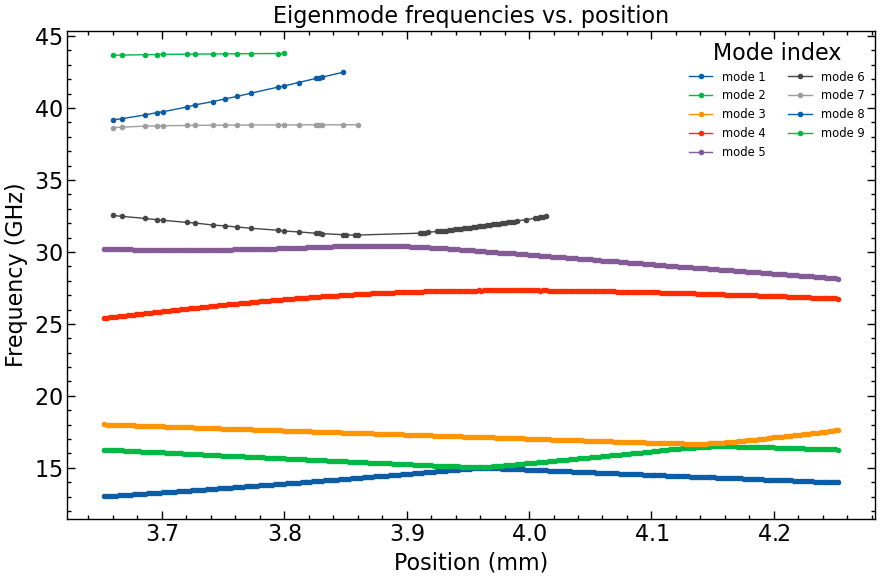

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

for mode_index, group in modes_df.groupby('mode_index'):
    group = group.sort_values('pos_mm')
    ax.plot(group['pos_mm'], group['f_ghz'], marker='o', markersize=3,
            linewidth=1, label=f'mode {mode_index}')

ax.set_xlabel('Position (mm)')
ax.set_ylabel('Frequency (GHz)')
ax.set_title('Eigenmode frequencies vs. position')
ax.legend(title='Mode index', ncol=2, fontsize='small')
fig.tight_layout()
plt.show()

## Same plot, scatter only (no connecting lines)
Useful if mode ordering by index isn't physically meaningful between neighboring positions (e.g. if two modes cross).

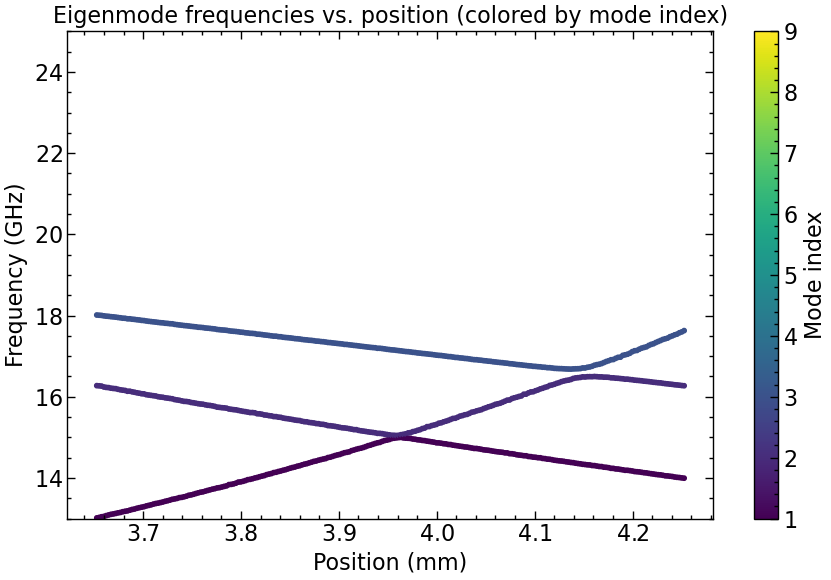

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(modes_df['pos_mm'], modes_df['f_ghz'], c=modes_df['mode_index'],
                 cmap='viridis', s=10)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Mode index')

ax.set_xlabel('Position (mm)')
ax.set_ylabel('Frequency (GHz)')
ax.set_title('Eigenmode frequencies vs. position (colored by mode index)')
ax.set_ylim(13, 25)
fig.tight_layout()
plt.show()